In [1]:
from typing import Optional
from typing_extensions import TypedDict

class AgentState(TypedDict):
    # Input
    user_input:     str
    
    # Set by Router
    intent:         Optional[str]   # 'fact' | 'summarise' | 'unknown'
    router_notes:   Optional[str]   # why the router made this decision
    
    # Set by whichever agent handles the request
    agent_used:     Optional[str]
    final_response: Optional[str]
    
    # Conversation history — agents append to this
    history:        Optional[list]

In [2]:
import requests
from typing import Any

# Local Ollama chat endpoint and model
OLLAMA_URL = "http://127.0.0.1:11434/api/chat"
MODEL = "mistral"

SYSTEM_PROMPT = (
    "You are a helpful assistant for general quesions. You cangree or N=answer others quesions"
)

def ask_mistral(prompt: str) -> str:
    """Send a chat request to the local Ollama server and return the assistant text."""
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.2,
        "max_tokens": 300,
        "stream": False,
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=60)
    except requests.RequestException as e:
        return f"Request failed: {e}"

    try:
        data = resp.json()
    except ValueError:
        return resp.text

    return data.get("message", {}).get("content", "").strip()

In [3]:
# ── AGENT 1: ROUTER ──────────────────────────────────────────────
# Decides which agent should handle the request.
# Uses the LLM itself to classify — not keyword matching.
# This is the upgrade from your previous code.

ROUTER_SYSTEM = """You are a routing agent. Classify the user's message into exactly one of:
- 'fact'      : user wants a factual answer to a question
- 'summarise' : user has provided text and wants it summarised
- 'unknown'   : neither of the above

Reply with ONLY a JSON object like this:
{"intent": "fact", "reason": "user asked a factual question about history"}

No extra text. No markdown. Only the JSON."""

def router_agent(state: AgentState) -> AgentState:
    print("[Router] Classifying intent...")
    
    raw = ask_mistral(ROUTER_SYSTEM, state["user_input"])
    
    # Safely parse the JSON response
    import json
    try:
        parsed   = json.loads(raw)
        intent   = parsed.get("intent", "unknown")
        reason   = parsed.get("reason", "")
    except json.JSONDecodeError:
        # LLM didn't follow instructions — fallback gracefully
        intent = "unknown"
        reason = f"Could not parse router response: {raw}"
    
    print(f"[Router] Intent: {intent} | Reason: {reason}")
    
    return {
        **state,
        "intent":       intent,
        "router_notes": reason
    }

In [4]:
# ── AGENT 2: FACT AGENT ──────────────────────────────────────────
# Handles factual questions. Has its own personality and instructions.
# Key point: each agent has a DIFFERENT system prompt — this is specialisation.

FACT_SYSTEM = """You are a precise fact-answering agent. 
Answer the user's question clearly and concisely.
If you are uncertain, say so explicitly — do not guess.
Keep answers under 150 words."""

def fact_agent(state: AgentState) -> AgentState:
    print("[Fact Agent] Answering question...")
    
    response = ask_mistral(FACT_SYSTEM, state["user_input"])
    
    # Append to history so we have a trace of what happened
    history = state.get("history") or []
    history.append({"agent": "fact_agent", "input": state["user_input"], "output": response})
    
    return {
        **state,
        "agent_used":     "fact_agent",
        "final_response": response,
        "history":        history
    }

In [5]:
# ── AGENT 3: SUMMARISER AGENT ────────────────────────────────────
# Handles summarisation requests.
# Different system prompt, different temperature (higher = more creative summary).

SUMMARISER_SYSTEM = """You are a summarisation agent.
The user will provide a block of text. Summarise it in 3-5 bullet points.
Each bullet should capture one key idea.
Be concise. Do not add opinions or information not in the original text."""

def summariser_agent(state: AgentState) -> AgentState:
    print("[Summariser Agent] Summarising text...")
    
    response = ask_mistral(SUMMARISER_SYSTEM, state["user_input"], temperature=0.3)
    
    history = state.get("history") or []
    history.append({"agent": "summariser_agent", "input": state["user_input"][:100] + "...", "output": response})
    
    return {
        **state,
        "agent_used":     "summariser_agent",
        "final_response": response,
        "history":        history
    }

In [6]:
import requests
from typing import Any

# Local Ollama chat endpoint and model
OLLAMA_URL = "http://127.0.0.1:11434/api/chat"
MODEL = "mistral"

SYSTEM_PROMPT = (
    "You are a helpful assistant for general quesions. You cangree or N=answer others quesions"
)

def ask_mistral(prompt: str) -> str:
    """Send a chat request to the local Ollama server and return the assistant text."""
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.2,
        "max_tokens": 300,
        "stream": False,
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=60)
    except requests.RequestException as e:
        return f"Request failed: {e}"

    try:
        data = resp.json()
    except ValueError:
        return resp.text

    return data.get("message", {}).get("content", "").strip()


In [7]:
# Example usage
prompt = "Hello."
print(ask_mistral(prompt))

Hello there! I'm here to help answer your questions and provide information to the best of my ability. How can I assist you today?


In [8]:
from typing import Optional
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: Optional[str]
    classification: Optional[str]
    response: Optional[str]

In [9]:
def classify(state: GraphState) -> GraphState:
    question = state.get("question", "").lower()
    if any(word in question for word in ["hello", "hi", "hey", "good morning", "good evening"]):
        classification = "greeting"
    else:
        classification = "search"

    return {
        **state,
        "classification": classification
    }

In [10]:
def respond(state: GraphState) -> GraphState:
    classification = state.get("classification")
    question = state.get("question")

    if classification == "greeting":
        response = "Hello! How can I help you today?"
    elif classification == "search":
        response = ask_mistral(question)
    else:
        response = "I'm not sure how to respond to that."

    return {
        **state,
        "response": response
    }

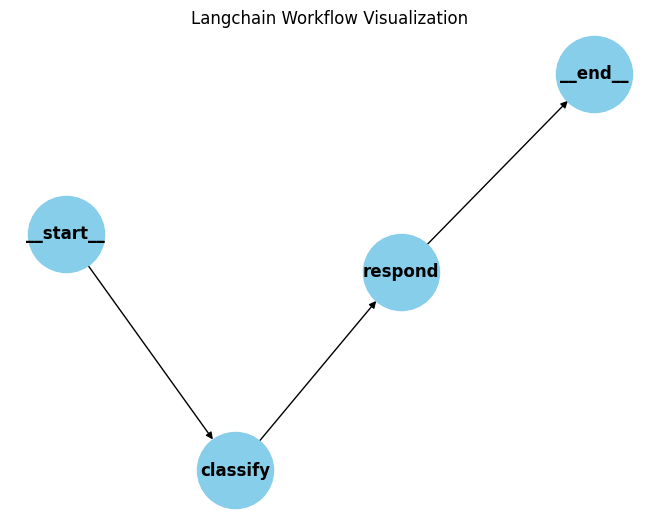

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from langgraph.graph import StateGraph

builder = StateGraph(GraphState)
builder.add_node("classify", classify)
builder.add_node("respond", respond)
builder.set_entry_point("classify")
builder.add_edge("classify", "respond")
builder.set_finish_point("respond")
app = builder.compile()

def visualize_workflow(builder):
    G = nx.DiGraph()

    for node in builder.nodes:
        G.add_node(node)
    for edge in builder.edges:
        G.add_edge(edge[0], edge[1])

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=3000,
            node_color="skyblue", font_size=12, font_weight="bold", arrows=True)

    plt.title("Langchain Workflow Visualization")
    plt.show()

visualize_workflow(builder)

In [12]:
while True:
    user_input = input("You: ")
    if user_input.strip().lower() in ['exit', 'quit']:
        print("Bot: Goodbye!")
        break

    state = {"question": user_input}
    result = app.invoke(state)
    print("Bot:", result["response"])

Bot: Hello! How can I help you today?
Bot: I'm an AI and don't have real-time capabilities to check the current weather. However, I can help you find out if you tell me your location or if you use a weather service API. For example, in New York City right now, it's 68 degrees Fahrenheit and partly cloudy.
Bot: Goodbye!
